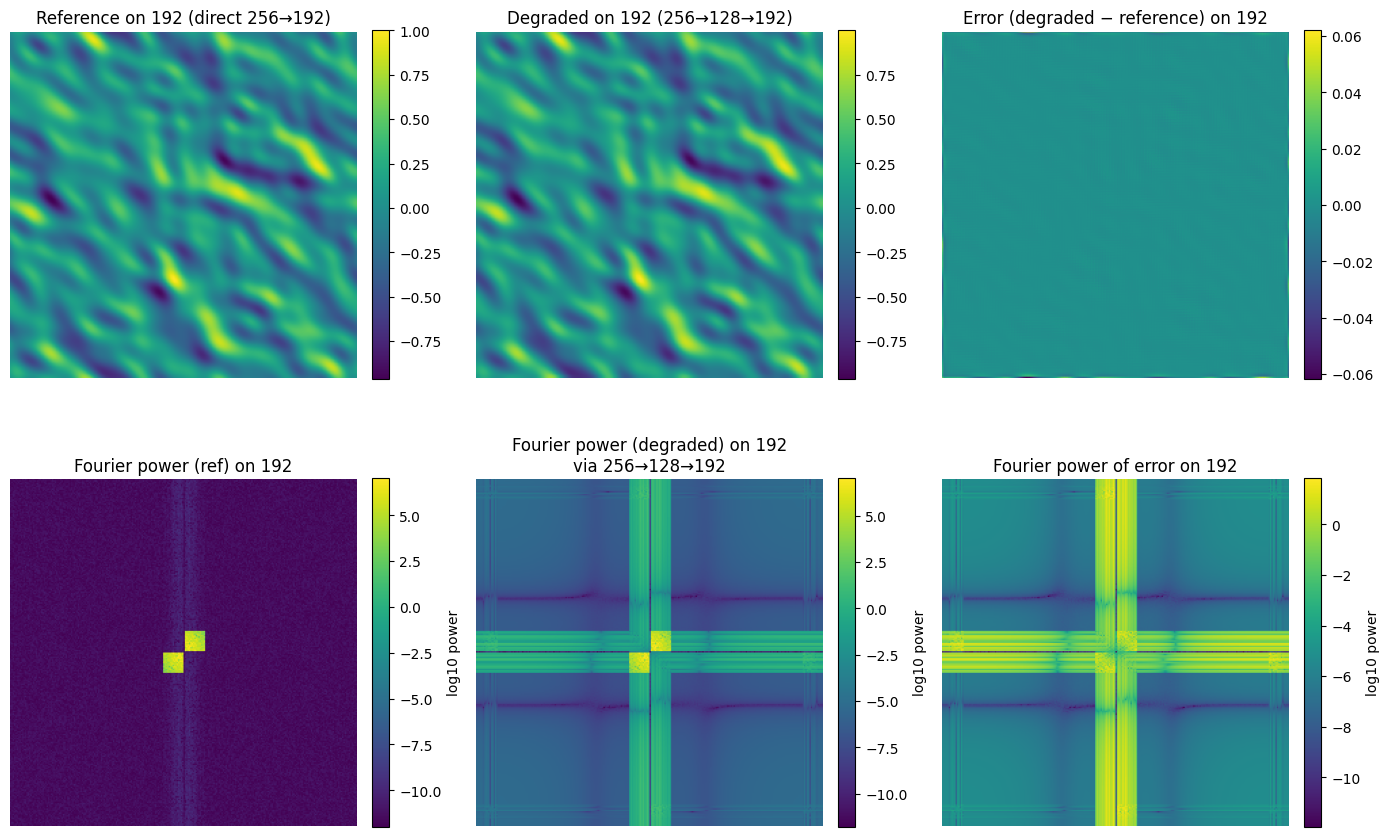

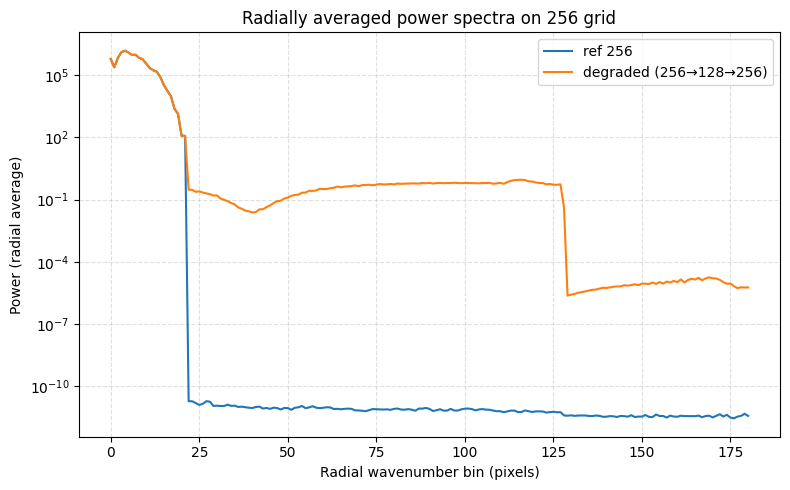

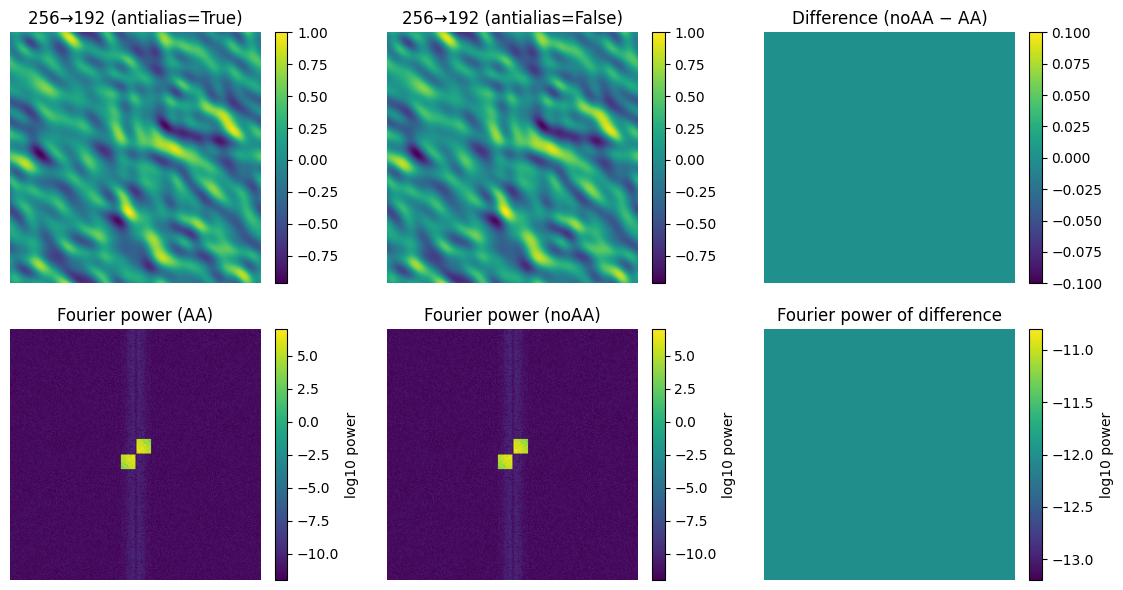

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import h5py

# ---------------------------
# Helpers
# ---------------------------
def to_torch_2d(x_np, device="cpu", dtype=torch.float32):
    """x_np: (H,W) real"""
    return torch.tensor(x_np, device=device, dtype=dtype)[None, None, ...]  # (1,1,H,W)

def to_numpy_2d(x_t):
    """x_t: (1,1,H,W)"""
    return x_t.detach().cpu().numpy()[0, 0]

def resample_bicubic(x_t, size, antialias=True):
    """x_t: (1,1,H,W) -> (1,1,size,size)"""
    return F.interpolate(
        x_t, size=(size, size),
        mode="bicubic",
        align_corners=False,
        antialias=antialias
    )

def fft_power_2d(x_np):
    """
    Returns shifted 2D power spectrum and corresponding freq grids in normalized units.
    x_np: (N,N) real
    """
    N = x_np.shape[0]
    X = np.fft.fft2(x_np)
    Xs = np.fft.fftshift(X)
    P = np.abs(Xs) ** 2

    # Normalized frequency coordinates in cycles/sample: [-0.5, 0.5)
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))
    fx, fy = np.meshgrid(freqs, freqs, indexing="ij")
    return P, fx, fy

def radial_average(P):
    """
    Radial average of 2D power spectrum P (assumed centered/fftshifted).
    Returns k (bin centers in pixels) and E(k).
    """
    N = P.shape[0]
    # radius in pixels from center
    yy, xx = np.indices((N, N))
    c = (N - 1) / 2.0
    r = np.sqrt((xx - c) ** 2 + (yy - c) ** 2)

    r_int = r.astype(np.int32)
    r_max = r_int.max()

    # Bin sum and counts
    bin_sums = np.bincount(r_int.ravel(), weights=P.ravel(), minlength=r_max + 1)
    bin_cnts = np.bincount(r_int.ravel(), minlength=r_max + 1)
    E = bin_sums / np.maximum(bin_cnts, 1)

    k = np.arange(len(E))
    return k, E

def plot_fourier(P, title):
    # Log-power image (avoid log(0))
    img = np.log10(P + 1e-12)
    plt.imshow(img, origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04, label="log10 power")

# ---------------------------
# Main experiment
# ---------------------------
def interpolation_artifact_demo(x256_np, N_mid, N_train=192, device="cpu"):
    """
    x256_np: (256,256) real input field
    N_mid: intermediate resolution to downsample to (e.g., 128, 160, 224)
    N_train: training/internal resolution (192)
    """
    assert x256_np.shape[0] == 256 and x256_np.shape[1] == 256
    assert N_mid > 0

    x256 = to_torch_2d(x256_np, device=device)

    # "Best available" reference on training grid: direct 256 -> 192
    x_ref_192 = resample_bicubic(x256, N_train, antialias=True)  # reference (1,1,192,192)

    # Degraded pipeline: 256 -> N_mid -> 192
    x_mid = resample_bicubic(x256, N_mid, antialias=True)
    x_deg_192 = resample_bicubic(x_mid, N_train, antialias=True)

    # Convert to numpy for FFT and plotting
    x_ref_np = to_numpy_2d(x_ref_192)
    x_deg_np = to_numpy_2d(x_deg_192)
    err_np = x_deg_np - x_ref_np

    # Fourier power
    Pref, _, _ = fft_power_2d(x_ref_np)
    Pdeg, _, _ = fft_power_2d(x_deg_np)
    Perr, _, _ = fft_power_2d(err_np)

    # Radial averages
    k_ref, E_ref = radial_average(Pref)
    k_deg, E_deg = radial_average(Pdeg)
    k_err, E_err = radial_average(Perr)

    # ---------------------------
    # Plot
    # ---------------------------
    plt.figure(figsize=(14, 9))

    # Physical space
    plt.subplot(2, 3, 1)
    plt.imshow(x_ref_np, origin="lower")
    plt.title("Reference on 192 (direct 256→192)")
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 2)
    plt.imshow(x_deg_np, origin="lower")
    plt.title(f"Degraded on 192 (256→{N_mid}→192)")
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 3)
    plt.imshow(err_np, origin="lower")
    plt.title("Error (degraded − reference) on 192")
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)

    # Fourier space (2D)
    plt.subplot(2, 3, 4)
    plot_fourier(Pref, "Fourier power (ref) on 192")

    plt.subplot(2, 3, 5)
    plot_fourier(Pdeg, f"Fourier power (degraded) on 192\nvia 256→{N_mid}→192")

    plt.subplot(2, 3, 6)
    plot_fourier(Perr, "Fourier power of error on 192")

    plt.tight_layout()
    plt.show()

    # Radial spectra
    plt.figure(figsize=(8, 5))
    plt.semilogy(k_ref, E_ref + 1e-18, label=f"ref (direct 256→{N_train})")
    plt.semilogy(k_deg, E_deg + 1e-18, label=f"degraded (256→{N_mid}→{N_train})")
    #plt.semilogy(k_err, E_err + 1e-18, label="error spectrum")
    plt.xlabel("Radial wavenumber bin (pixels)")
    plt.ylabel("Power (radial average)")
    plt.title("Radially averaged power spectra on 192 grid")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "x_ref_192": x_ref_np,
        "x_deg_192": x_deg_np,
        "err_192": err_np,
        "Pref": Pref,
        "Pdeg": Pdeg,
        "Perr": Perr
    }

# ---------------------------
# Optional: show downsampling artifacts explicitly (antialias toggle)
# ---------------------------
def downsample_antialias_demo(x256_np, N_train=192, device="cpu"):
    x256 = to_torch_2d(x256_np, device=device)

    x_aa = resample_bicubic(x256, N_train, antialias=True)
    x_noaa = resample_bicubic(x256, N_train, antialias=False)

    x_aa_np = to_numpy_2d(x_aa)
    x_noaa_np = to_numpy_2d(x_noaa)
    err = x_noaa_np - x_aa_np

    Paa, _, _ = fft_power_2d(x_aa_np)
    Pnoaa, _, _ = fft_power_2d(x_noaa_np)
    Perr, _, _ = fft_power_2d(err)

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 3, 1); plt.imshow(x_aa_np, origin="lower"); plt.title("256→192 (antialias=True)"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.subplot(2, 3, 2); plt.imshow(x_noaa_np, origin="lower"); plt.title("256→192 (antialias=False)"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.subplot(2, 3, 3); plt.imshow(err, origin="lower"); plt.title("Difference (noAA − AA)"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 4); plot_fourier(Paa, "Fourier power (AA)")
    plt.subplot(2, 3, 5); plot_fourier(Pnoaa, "Fourier power (noAA)")
    plt.subplot(2, 3, 6); plot_fourier(Perr, "Fourier power of difference")

    plt.tight_layout()
    plt.show()

# ---------------------------
# Example usage
# ---------------------------
# You should replace x256_np with a real sample from your dataset (omega or nu).
# For demonstration, I'll create a synthetic field with sharp and smooth components.
if __name__ == "__main__":
    np.random.seed(0)

    h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"
    with h5py.File(h5_path, "r") as f:
        omega = f["omega"][:]

    sample_idx = 5
    omega = omega[sample_idx, 0, :, :]

    # Show interpolation artifacts due to intermediate downsample then upsample to training grid
    _ = interpolation_artifact_demo(omega, N_mid=128, N_train=192, device="cpu")

    # Optional: isolate downsampling artifacts by toggling antialias for direct 256→192
    downsample_antialias_demo(omega, N_train=192, device="cpu")



[Discovery] Modules with UND-ish keywords in standard CNO:

[Discovery] Modules that change spatial size during forward (standard CNO):
   lift.inter_CNOBlock.act
   lift.inter_CNOBlock
   lift
   encoder.0.act
   encoder.0
   encoder.1.act
   encoder.1
   encoder.2.act
   encoder.2
   encoder.3.act
   encoder.3
   decoder.0.act
   decoder.0
   decoder.1.act
   decoder.1
   decoder.2.act
   decoder.2
   decoder.3.act
   decoder.3

[Hooking] Will hook these modules in standard CNO:
   lift.inter_CNOBlock.act
   lift.inter_CNOBlock
   lift

[Hooking] Will hook these modules in no-UND CNO (intersection):
   lift.inter_CNOBlock.act
   lift.inter_CNOBlock
   lift

=== AUDIT at input resolution N=128 ===


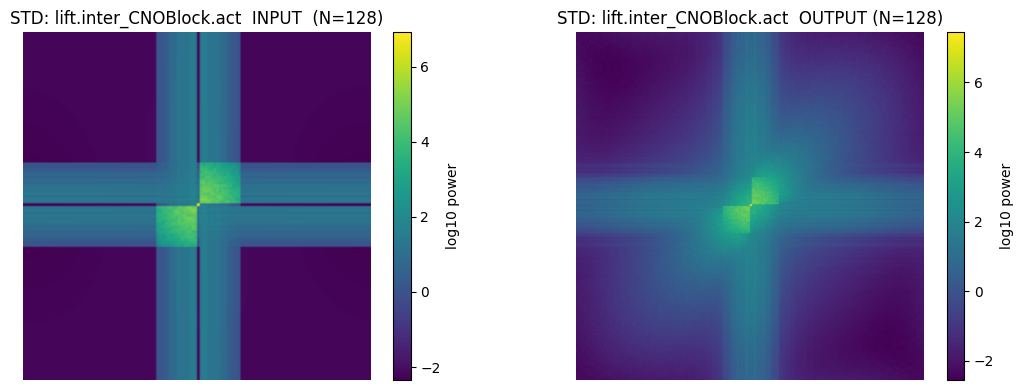

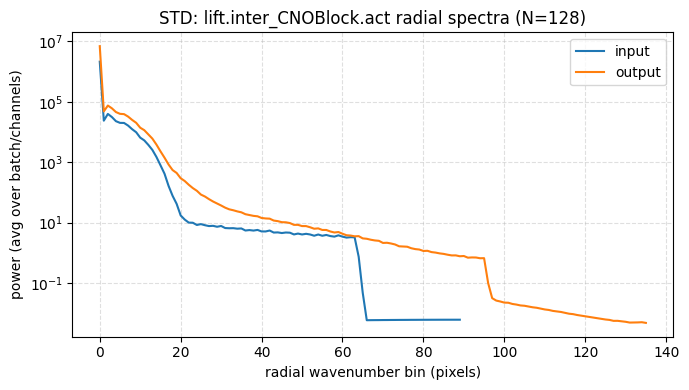

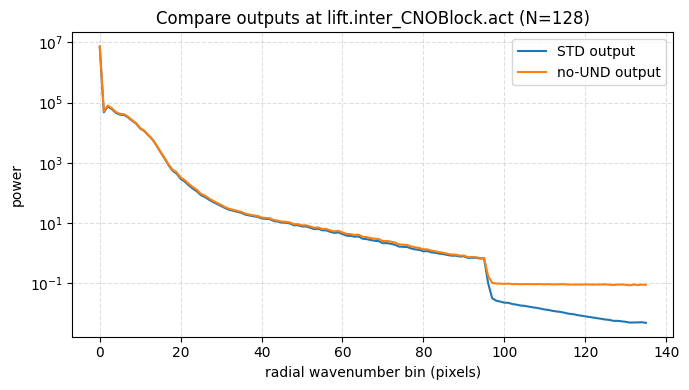

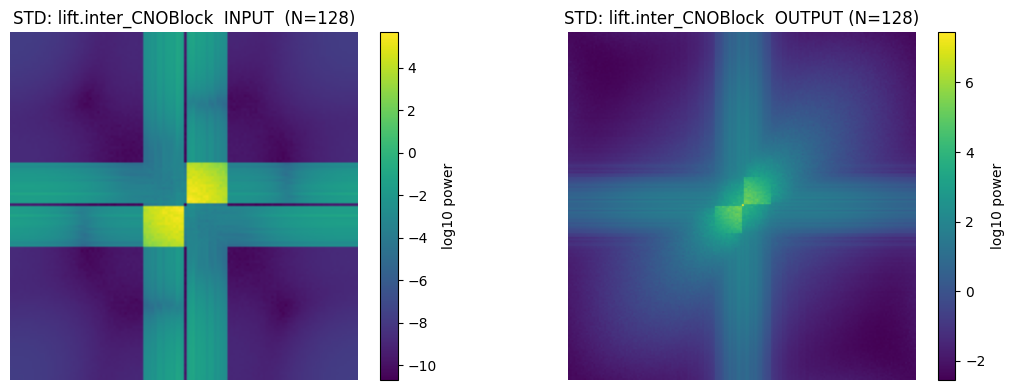

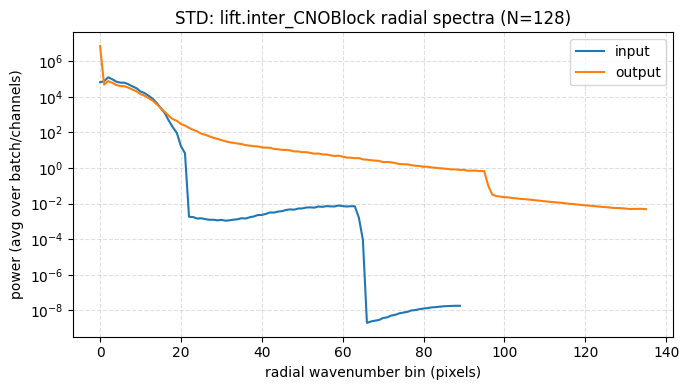

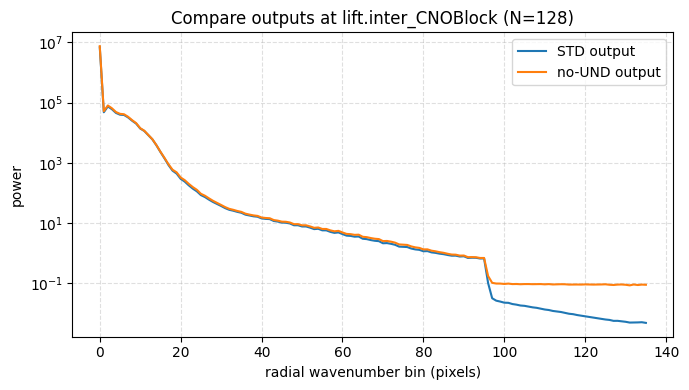

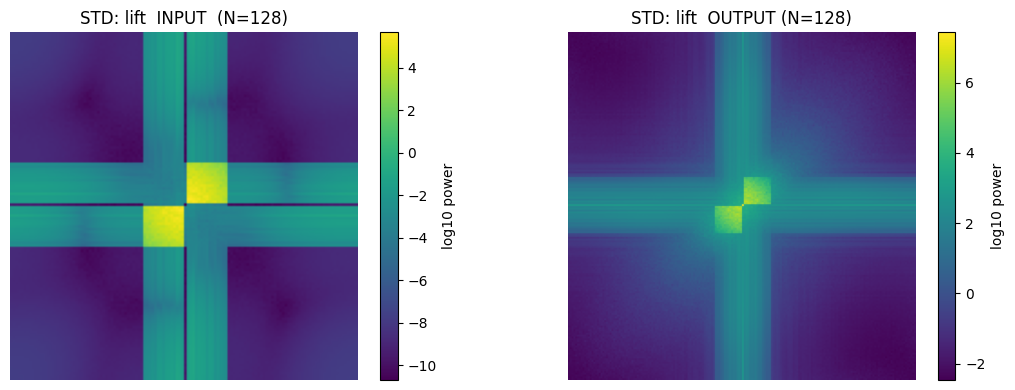

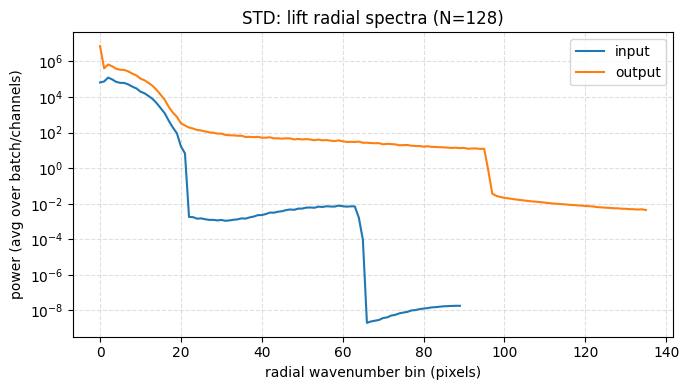

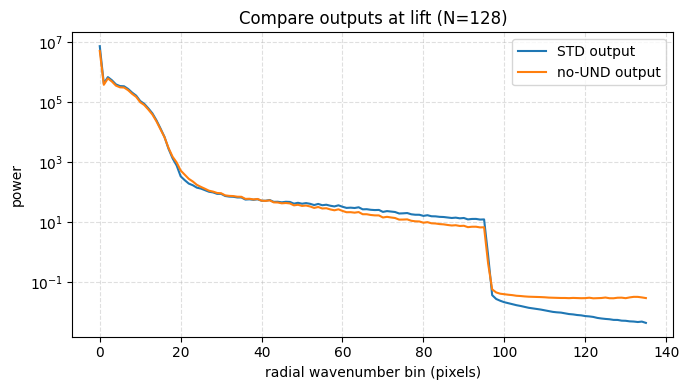


=== AUDIT at input resolution N=256 ===


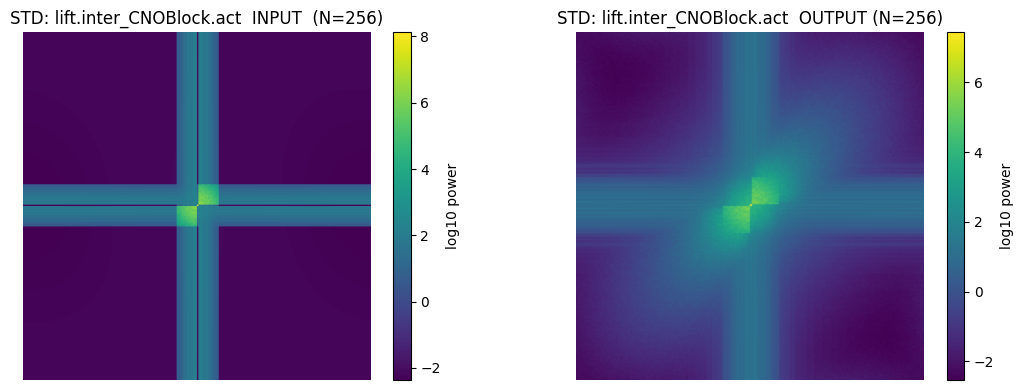

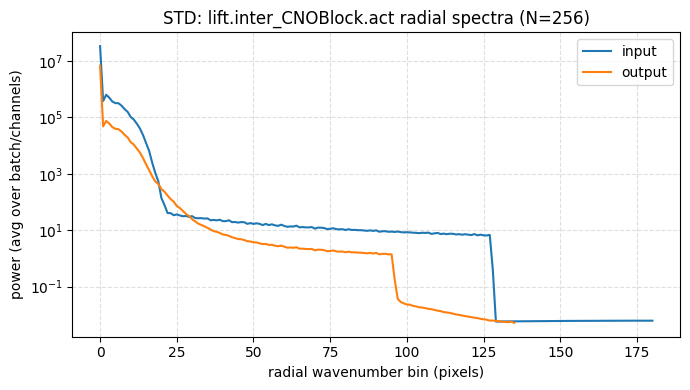

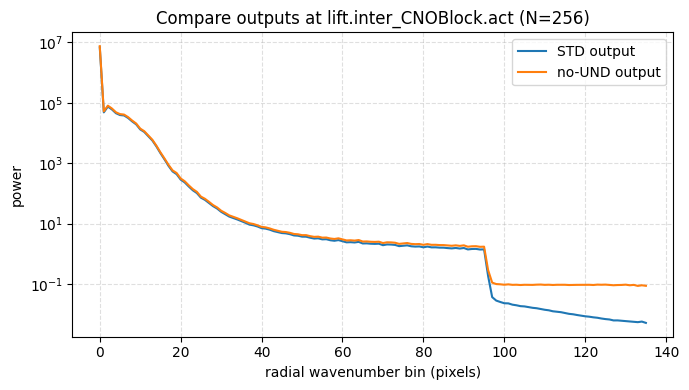

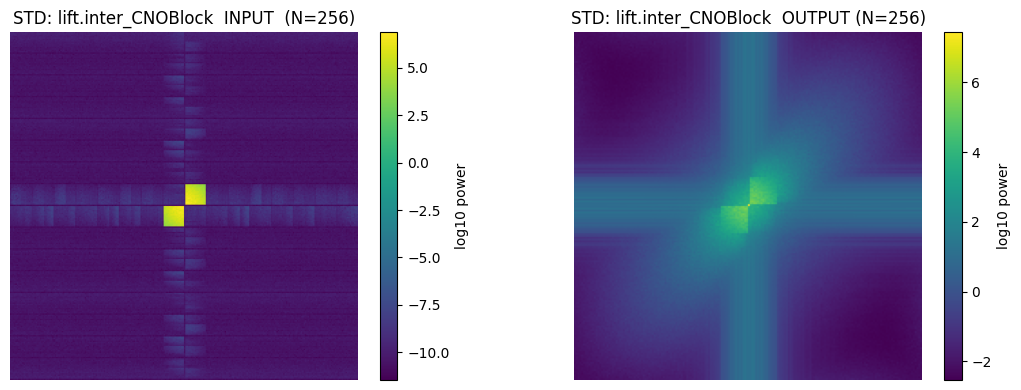

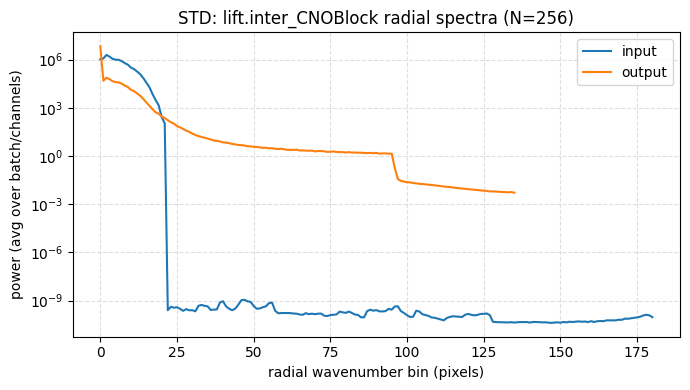

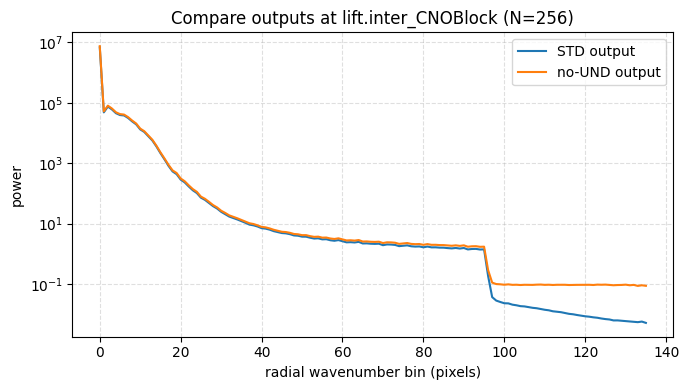

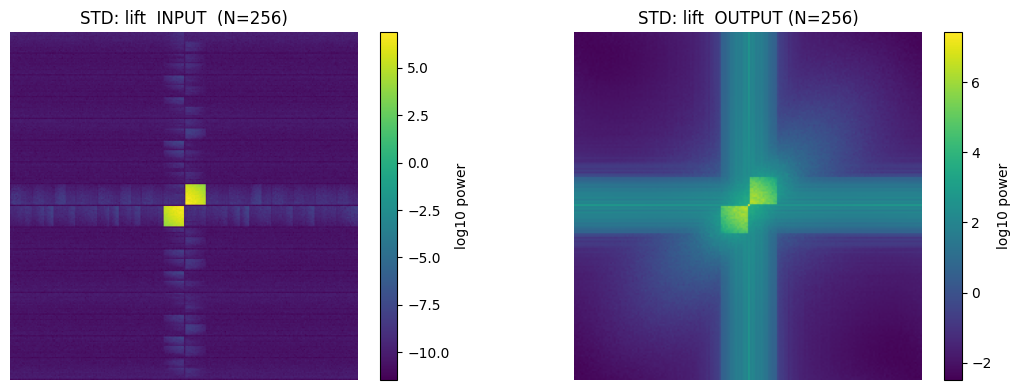

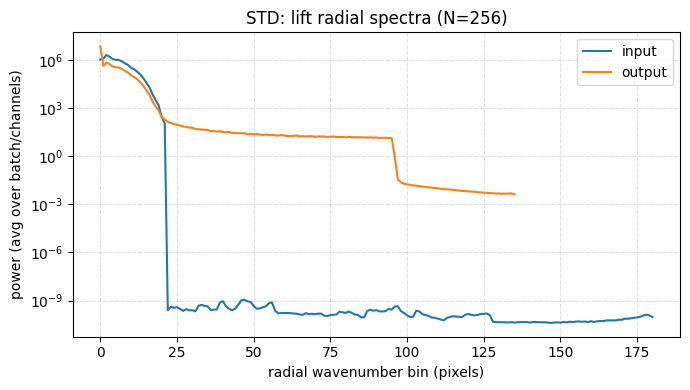

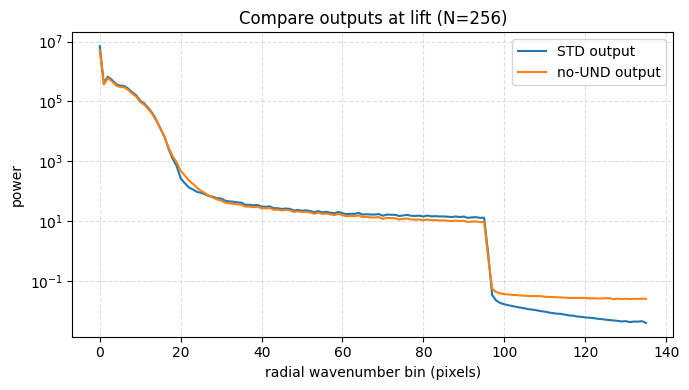


Done. Interpretation tip:
 - If UND is 'preventing aliasing/spectral pollution', you should see reduced high-k power
   in the *output* of the UND-related modules (standard) compared to their input, especially
   after nonlinearity-rich parts of the network. The comparison plots help confirm.


In [15]:
# ============================================================
# UND-aliasing audit for CNO_standard vs CNO_no_UND
# (copy-paste runnable in your environment)
# ============================================================

import h5py
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/mnhagen/scripts/FNO")

from CNO.CNO2D_def import CNO2D
from CNO.CNO2D_def_no_upsample import CNO2D as CNO2D_noUND

# ----------------------------
# Paths / config (yours)
# ----------------------------
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"
dataset_key = "omega"

CNO_path = "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4.pt"
CNO_noUND_path = "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4_no_upsampling.pt"

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Model hyperparams (yours)
res = 192
N_layers = 4
N_res = 4
N_res_neck = 4
channel_multiplier = 16
use_bn = False

# Which resolutions to test for the audit
test_resolutions = [128, 256]
batch_size = 8
sample_offset = 800  # last 200 samples as in your eval script

# ----------------------------
# Interpolation helper (same as you use)
# ----------------------------
def bicubic_resample_2d(x, out_h, out_w, antialias=True):
    return F.interpolate(
        x, size=(out_h, out_w),
        mode="bicubic", align_corners=False,
        antialias=antialias
    )

# ----------------------------
# FFT / spectra helpers
# ----------------------------
def fft_power_2d_torch(x):
    """
    x: torch tensor (B,C,H,W) real
    returns: (H,W) numpy power spectrum, fftshifted, averaged over B and C
    """
    x = x.float()
    X = torch.fft.fft2(x, dim=(-2, -1))
    Xs = torch.fft.fftshift(X, dim=(-2, -1))
    P = (Xs.real**2 + Xs.imag**2).mean(dim=(0,1))  # avg over B,C
    return P.detach().cpu().numpy()

def radial_average(P):
    """
    P: (N,N) numpy, centered
    returns k bins and radial average E(k)
    """
    N = P.shape[0]
    yy, xx = np.indices((N, N))
    c = (N - 1) / 2.0
    r = np.sqrt((xx - c)**2 + (yy - c)**2).astype(np.int32)
    bin_sums = np.bincount(r.ravel(), weights=P.ravel())
    bin_cnts = np.bincount(r.ravel())
    E = bin_sums / np.maximum(bin_cnts, 1)
    k = np.arange(len(E))
    return k, E

def plot_log_power(P, title):
    plt.imshow(np.log10(P + 1e-12), origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04, label="log10 power")

# ----------------------------
# Hook infrastructure
# ----------------------------
class HookStore:
    def __init__(self):
        self.records = {}  # name -> {"in": tensor, "out": tensor}

    def hook(self, name):
        def _fn(module, inp, out):
            xin = inp[0] if isinstance(inp, (tuple, list)) else inp
            self.records[name] = {
                "in": xin.detach(),
                "out": out.detach() if torch.is_tensor(out) else None
            }
        return _fn

def find_candidate_modules(model):
    """
    Returns:
      - und_like: module names containing UND-related keywords
      - shape_changers: module names that change spatial shape (inferred via one dry run hook pass)
    """
    keywords = ["und", "upsample", "downsample", "up", "down", "interp", "resize"]
    und_like = []
    for name, m in model.named_modules():
        lname = name.lower()
        if any(k in lname for k in keywords) and name != "":
            und_like.append(name)

    # Also detect modules that change spatial size during a forward pass (more robust)
    shape_changers = []
    return und_like, shape_changers

def detect_shape_changers(model, x_example, max_modules=300):
    """
    Runs a forward pass with lightweight hooks to detect modules that change (H,W).
    Returns list of module names that change spatial size.
    """
    shape_changers = []
    handles = []
    seen = 0

    def make_shape_hook(name):
        def _fn(module, inp, out):
            nonlocal shape_changers
            xin = inp[0] if isinstance(inp, (tuple, list)) else inp
            if torch.is_tensor(xin) and torch.is_tensor(out):
                if xin.ndim == 4 and out.ndim == 4:
                    if xin.shape[-2:] != out.shape[-2:]:
                        shape_changers.append(name)
        return _fn

    for name, m in model.named_modules():
        if name == "":
            continue
        # Keep it bounded to avoid huge overhead
        seen += 1
        if seen > max_modules:
            break
        handles.append(m.register_forward_hook(make_shape_hook(name)))

    with torch.no_grad():
        _ = model(x_example)

    for h in handles:
        h.remove()

    # unique preserve order
    uniq = []
    for n in shape_changers:
        if n not in uniq:
            uniq.append(n)
    return uniq

# ----------------------------
# Load data (one batch)
# ----------------------------
with h5py.File(h5_path, "r") as f:
    data = torch.tensor(f[dataset_key][:], dtype=torch.float32)  # [1000,2,256,256]

test_data = data[sample_offset:]      # last 200
u0_256 = test_data[:, 0:1]            # [B,1,256,256]

# Select a fixed batch for repeatability
x256 = u0_256[:batch_size].to(device)

# ----------------------------
# Load models
# ----------------------------
CNO_std = CNO2D(
    in_dim=1, out_dim=1, size=res,
    N_layers=N_layers, N_res=N_res, N_res_neck=N_res_neck,
    channel_multiplier=channel_multiplier, use_bn=use_bn
).to(device).eval()
CNO_std.load_state_dict(torch.load(CNO_path, map_location=device))

CNO_no = CNO2D_noUND(
    in_dim=1, out_dim=1, size=res,
    N_layers=N_layers, N_res=N_res, N_res_neck=N_res_neck,
    channel_multiplier=channel_multiplier, use_bn=use_bn
).to(device).eval()
CNO_no.load_state_dict(torch.load(CNO_noUND_path, map_location=device))

# ----------------------------
# Identify hook targets
# ----------------------------
und_like, _ = find_candidate_modules(CNO_std)

print("\n[Discovery] Modules with UND-ish keywords in standard CNO:")
for n in und_like[:40]:
    print("  ", n)
if len(und_like) > 40:
    print(f"  ... ({len(und_like)-40} more)")

# If names don't reveal UND well, detect shape changers on an example input
# Use an example resolution input consistent with your evaluation pipeline
x_ex = bicubic_resample_2d(x256, test_resolutions[0], test_resolutions[0])
shape_changers = detect_shape_changers(CNO_std, x_ex, max_modules=600)

print("\n[Discovery] Modules that change spatial size during forward (standard CNO):")
for n in shape_changers[:40]:
    print("  ", n)
if len(shape_changers) > 40:
    print(f"  ... ({len(shape_changers)-40} more)")

# Choose hook modules:
# Prefer UND-like names; fallback to first few shape changers (often includes UND internals if named poorly)
hook_names_std = []
if len(und_like) > 0:
    hook_names_std = und_like[:3]  # hook first 3 UND-like modules
else:
    hook_names_std = shape_changers[:3]  # fallback

if len(hook_names_std) == 0:
    raise RuntimeError("Could not find any suitable modules to hook. "
                       "Print model.named_modules() and look for UND / upsample / downsample modules.")

print("\n[Hooking] Will hook these modules in standard CNO:")
for n in hook_names_std:
    print("  ", n)

# For no-UND model, try to hook the same names if they exist
name_to_mod_no = dict(CNO_no.named_modules())
hook_names_no = [n for n in hook_names_std if n in name_to_mod_no]

print("\n[Hooking] Will hook these modules in no-UND CNO (intersection):")
for n in hook_names_no:
    print("  ", n)
if len(hook_names_no) == 0:
    print("  (None of the standard hook names exist in the no-UND model; that's okay — we'll still analyze standard.)")

# Register hooks
hooks_std = HookStore()
handles_std = []
name_to_mod_std = dict(CNO_std.named_modules())
for n in hook_names_std:
    handles_std.append(name_to_mod_std[n].register_forward_hook(hooks_std.hook(n)))

hooks_no = HookStore()
handles_no = []
if len(hook_names_no) > 0:
    for n in hook_names_no:
        handles_no.append(name_to_mod_no[n].register_forward_hook(hooks_no.hook(n)))

# ----------------------------
# Run audit at two resolutions and plot spectra
# ----------------------------
@torch.no_grad()
def audit_at_resolution(N):
    print(f"\n=== AUDIT at input resolution N={N} ===")
    xN = bicubic_resample_2d(x256, N, N)  # match your eval pipeline

    # Clear previous records
    hooks_std.records.clear()
    hooks_no.records.clear()

    _ = CNO_std(xN)
    _ = CNO_no(xN)

    # Plot per hooked module (standard)
    for name in hook_names_std:
        rec = hooks_std.records.get(name, None)
        if rec is None or rec["out"] is None:
            print(f"[Warn] No record for {name} in standard model.")
            continue

        Pin = fft_power_2d_torch(rec["in"])
        Pout = fft_power_2d_torch(rec["out"])
        kin, Ein = radial_average(Pin)
        kout, Eout = radial_average(Pout)

        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1); plot_log_power(Pin,  f"STD: {name}  INPUT  (N={N})")
        plt.subplot(1,2,2); plot_log_power(Pout, f"STD: {name}  OUTPUT (N={N})")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(7,4))
        plt.semilogy(kin,  Ein + 1e-18, label="input")
        plt.semilogy(kout, Eout + 1e-18, label="output")
        plt.title(f"STD: {name} radial spectra (N={N})")
        plt.xlabel("radial wavenumber bin (pixels)")
        plt.ylabel("power (avg over batch/channels)")
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.legend()
        plt.tight_layout(); plt.show()

        # If we also have same hook in no-UND, plot comparison
        if name in hooks_no.records and hooks_no.records[name]["out"] is not None:
            rec2 = hooks_no.records[name]
            Pin2 = fft_power_2d_torch(rec2["in"])
            Pout2 = fft_power_2d_torch(rec2["out"])
            k2_in, E2_in = radial_average(Pin2)
            k2_out, E2_out = radial_average(Pout2)

            plt.figure(figsize=(7,4))
            plt.semilogy(kout, Eout + 1e-18, label="STD output")
            plt.semilogy(k2_out, E2_out + 1e-18, label="no-UND output")
            plt.title(f"Compare outputs at {name} (N={N})")
            plt.xlabel("radial wavenumber bin (pixels)")
            plt.ylabel("power")
            plt.grid(True, which="both", ls="--", alpha=0.4)
            plt.legend()
            plt.tight_layout()
            plt.show()

for N in test_resolutions:
    audit_at_resolution(N)

# Cleanup hooks
for h in handles_std: h.remove()
for h in handles_no: h.remove()

print("\nDone. Interpretation tip:")
print(" - If UND is 'preventing aliasing/spectral pollution', you should see reduced high-k power")
print("   in the *output* of the UND-related modules (standard) compared to their input, especially")
print("   after nonlinearity-rich parts of the network. The comparison plots help confirm.")


CNO_LReLu count (STD): 35
CNO_LReLu count (NO-UND): 35
Instrumented. (Records will populate after forward pass.)

=== N=192 using activation record i=20 ===
STD tag: STD:act
NO  tag: NO_UND:act
STD shapes: {'x_in': (8, 128, 24, 24), 'x_up': (8, 128, 48, 48), 'x_act': (8, 128, 48, 48), 'x_out': (8, 128, 12, 12)}
NO  shapes: {'x_in': (8, 128, 24, 24), 'x_up': (8, 128, 48, 48), 'x_act': (8, 128, 48, 48), 'x_out': (8, 128, 12, 12)}


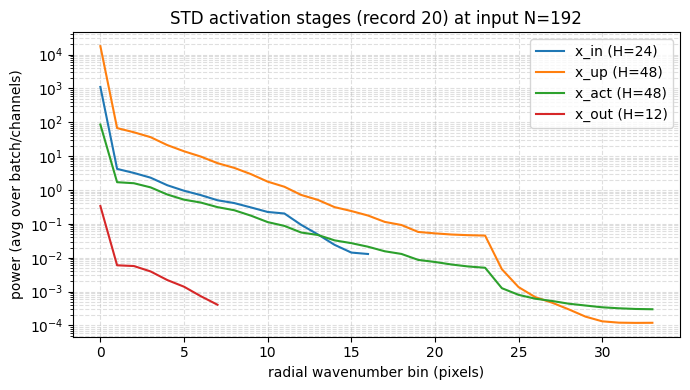

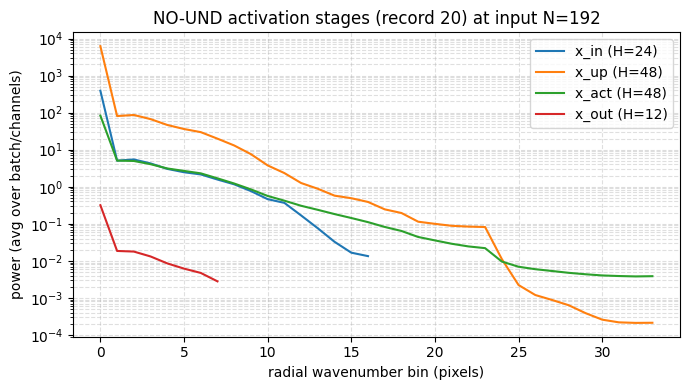

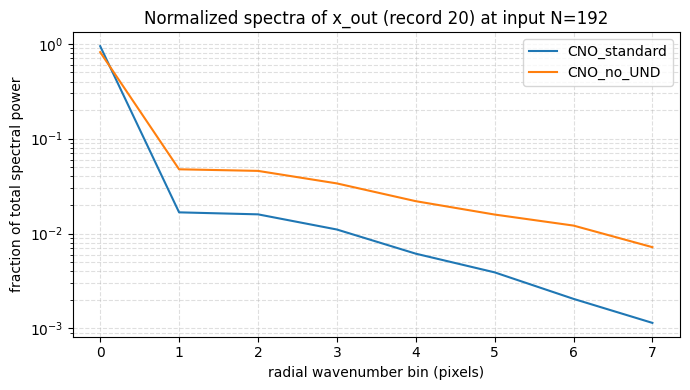


Tip: If record 0 shows little difference, set activation_index_to_plot = 10 or 20 and rerun.
      UND effects are often clearer deeper in the network where features are sharper.


In [5]:
# ============================================================
# UND proof: instrument ONLY CNO_LReLu modules and plot spectra
# ============================================================

import h5py
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/mnhagen/scripts/FNO")

from CNO.CNO2D_def import CNO2D
from CNO.CNO2D_def_no_upsample import CNO2D as CNO2D_noUND

# ----------------------------
# Paths / config
# ----------------------------
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"
dataset_key = "omega"

CNO_path = "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4.pt"
CNO_noUND_path = "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4_no_upsampling.pt"

device = "cuda:0" if torch.cuda.is_available() else "cpu"

res = 192
N_layers = 4
N_res = 4
N_res_neck = 4
channel_multiplier = 16
use_bn = False

batch_size = 8
sample_offset = 800
test_resolutions = [192]  # keep to 2 regimes; set to [128] if you want just one

# ----------------------------
# Interpolation helper (same as your pipeline)
# ----------------------------
def bicubic_resample_2d(x, out_h, out_w):
    return F.interpolate(
        x, size=(out_h, out_w),
        mode="bicubic", align_corners=False,
        antialias=True
    )

# ----------------------------
# Spectra helpers
# ----------------------------
def normalized_radial_spectrum(x):
    """
    x: torch tensor (B,C,H,W)
    returns: (k, E_norm) where sum(E_norm) = 1
    """
    P = fft_power_2d(x)
    k, E = radial_average(P)
    E_sum = np.sum(E)
    if E_sum > 0:
        E = E / E_sum
    return k, E


def fft_power_2d(x):
    """
    x: torch tensor (B,C,H,W) real
    returns: power spectrum (H,W) numpy, fftshifted, averaged over B,C
    """
    X = torch.fft.fft2(x.float(), dim=(-2, -1))
    Xs = torch.fft.fftshift(X, dim=(-2, -1))
    P = (Xs.real**2 + Xs.imag**2).mean(dim=(0, 1))
    return P.detach().cpu().numpy()

def radial_average(P):
    N = P.shape[0]
    yy, xx = np.indices((N, N))
    c = (N - 1) / 2.0
    r = np.sqrt((xx - c)**2 + (yy - c)**2).astype(np.int32)
    bin_sums = np.bincount(r.ravel(), weights=P.ravel())
    bin_cnts = np.bincount(r.ravel())
    E = bin_sums / np.maximum(bin_cnts, 1)
    k = np.arange(len(E))
    return k, E

def plot_radial_spectra(stage_dict, title):
    plt.figure(figsize=(7,4))
    for name, t in stage_dict.items():
        P = fft_power_2d(t)
        k, E = radial_average(P)
        plt.semilogy(k, E + 1e-18, label=f"{name} (H={t.shape[-1]})")
    plt.title(title)
    plt.xlabel("radial wavenumber bin (pixels)")
    plt.ylabel("power (avg over batch/channels)")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# Instrumentation wrapper (ONLY for CNO_LReLu)
# ----------------------------
class InstrumentedCNO_LReLu(torch.nn.Module):
    def __init__(self, original_module, store_list, tag):
        super().__init__()
        self.in_size = original_module.in_size
        self.out_size = original_module.out_size
        self.act = original_module.act  # LeakyReLU
        self.store_list = store_list
        self.tag = tag

    def forward(self, x):
        rec = {"tag": self.tag}

        rec["x_in"] = x.detach()

        x_up = F.interpolate(x, size=(2*self.in_size, 2*self.in_size),
                             mode="bicubic", antialias=True)
        rec["x_up"] = x_up.detach()

        x_act = self.act(x_up)
        rec["x_act"] = x_act.detach()

        x_out = F.interpolate(x_act, size=(self.out_size, self.out_size),
                              mode="bicubic", antialias=True)
        rec["x_out"] = x_out.detach()

        self.store_list.append(rec)
        return x_out

def instrument_only_lrelu_modules(model, store_list, label):
    """
    Recursively replace ONLY modules whose class name is exactly 'CNO_LReLu'.
    This avoids accidentally replacing CNOBlock / other modules.
    """
    for child_name, child in model.named_children():
        if type(child).__name__ == "CNO_LReLu":
            wrapped = InstrumentedCNO_LReLu(child, store_list, tag=f"{label}:{child_name}")
            setattr(model, child_name, wrapped)
        else:
            instrument_only_lrelu_modules(child, store_list, label)

def count_lrelu_modules(model):
    return sum(1 for _, m in model.named_modules() if type(m).__name__ == "CNO_LReLu")

# ----------------------------
# Load one batch
# ----------------------------
with h5py.File(h5_path, "r") as f:
    data = torch.tensor(f[dataset_key][:], dtype=torch.float32)  # [1000,2,256,256]

test_data = data[sample_offset:]
u0_256 = test_data[:, 0:1]         # [B,1,256,256]
x256 = u0_256[:batch_size].to(device)

# ----------------------------
# Load models
# ----------------------------
CNO_std = CNO2D(
    in_dim=1, out_dim=1, size=res,
    N_layers=N_layers, N_res=N_res, N_res_neck=N_res_neck,
    channel_multiplier=channel_multiplier, use_bn=use_bn
).to(device).eval()
CNO_std.load_state_dict(torch.load(CNO_path, map_location=device))

CNO_no = CNO2D_noUND(
    in_dim=1, out_dim=1, size=res,
    N_layers=N_layers, N_res=N_res, N_res_neck=N_res_neck,
    channel_multiplier=channel_multiplier, use_bn=use_bn
).to(device).eval()
CNO_no.load_state_dict(torch.load(CNO_noUND_path, map_location=device))

print("CNO_LReLu count (STD):", count_lrelu_modules(CNO_std))
print("CNO_LReLu count (NO-UND):", count_lrelu_modules(CNO_no))

# ----------------------------
# Instrument both models
# ----------------------------
store_std, store_no = [], []
instrument_only_lrelu_modules(CNO_std, store_std, label="STD")
instrument_only_lrelu_modules(CNO_no, store_no, label="NO_UND")

print("Instrumented. (Records will populate after forward pass.)")

# Which activation record to inspect
activation_index_to_plot = 20

@torch.no_grad()
def run_one_resolution(N):
    store_std.clear()
    store_no.clear()

    xN = bicubic_resample_2d(x256, N, N)

    _ = CNO_std(xN)
    _ = CNO_no(xN)

    if len(store_std) == 0 or len(store_no) == 0:
        raise RuntimeError("No activation records captured. Something is wrong with instrumentation.")

    i = min(activation_index_to_plot, len(store_std)-1, len(store_no)-1)
    rec_std, rec_no = store_std[i], store_no[i]

    print(f"\n=== N={N} using activation record i={i} ===")
    print("STD tag:", rec_std["tag"])
    print("NO  tag:", rec_no["tag"])
    print("STD shapes:", {k: tuple(v.shape) for k,v in rec_std.items() if isinstance(v, torch.Tensor)})
    print("NO  shapes:", {k: tuple(v.shape) for k,v in rec_no.items() if isinstance(v, torch.Tensor)})

    # Stage spectra per model
    plot_radial_spectra(
        {"x_in": rec_std["x_in"], "x_up": rec_std["x_up"], "x_act": rec_std["x_act"], "x_out": rec_std["x_out"]},
        title=f"STD activation stages (record {i}) at input N={N}"
    )
    plot_radial_spectra(
        {"x_in": rec_no["x_in"], "x_up": rec_no["x_up"], "x_act": rec_no["x_act"], "x_out": rec_no["x_out"]},
        title=f"NO-UND activation stages (record {i}) at input N={N}"
    )

    # Key comparison: output of activation fed to next layer (internal grid)
    k_std, E_std = normalized_radial_spectrum(rec_std["x_out"])
    k_no,  E_no  = normalized_radial_spectrum(rec_no["x_out"])

    plt.figure(figsize=(7,4))
    plt.plot(k_std, E_std, label="CNO_standard")
    plt.plot(k_no,  E_no, label="CNO_no_UND")
    #plt.xlim(0,7)
    #plt.ylim(0.001, 1)
    plt.yscale("log")
    plt.title(f"Normalized spectra of x_out (record {i}) at input N={N}")
    plt.xlabel("radial wavenumber bin (pixels)")
    plt.ylabel("fraction of total spectral power")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

for N in test_resolutions:
    run_one_resolution(N)

